In [11]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Define file paths
input_path = "../project/LSWMD.pkl"
output_path = "Dataset.pkl"

# 2. Check and print original file size
file_size_mb = os.path.getsize(input_path) / (1024 * 1024)
print(f"Original file size: {file_size_mb:.2f} MB")

# 3. Patch for backward compatibility with old pandas pickle files
sys.modules['pandas.indexes'] = pd.core.indexes
sys.modules['pandas.indexes.base'] = pd.core.indexes.base

# 4. Load the dataset
with open(input_path, "rb") as f:
    df = pickle.load(f, encoding="latin1")

print("Dataset successfully loaded!")

# 5. Define filter function for valid labels
def is_valid_label(label):
    # Handle nested lists or numpy arrays
    while isinstance(label, (np.ndarray, list)):
        if len(label) == 0:
            return False  # Discard empty arrays []
        label = label[0]
    
    # Convert to lowercase string to be safe
    label_str = str(label).strip().lower()
    
    # Return True only if it's explicitly training or test
    return label_str in ['training', 'test']

# 6. Apply the filter to the DataFrame
df = df[df['trianTestLabel'].apply(is_valid_label)]

# 7. Reset the index (highly recommended after dropping rows)
df = df.reset_index(drop=True)

# Print remaining rows
print(f"Remaining rows after filtering: {len(df)}")
display(df.head())

# 8. Save the clean dataset to a modern, compatible pickle file
df.to_pickle(output_path)
print(f"Clean dataset saved to: {output_path}")

Original file size: 1998.43 MB
Dataset successfully loaded!
Remaining rows after filtering: 172950


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


Clean dataset saved to: Dataset.pkl


In [3]:
df = pd.read_pickle("../project/Dataset.pkl")

display(df.head())

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## Struttura del Dataset WM-811K

**`waferMap`**
* **Formato:** Matrice (array 2D) di numeri.
* **Significato:** È la rappresentazione spaziale vera e propria del disco. I numeri all'interno dell'array codificano lo stato di ogni singolo spazio (es. `0` = sfondo/nessun chip, `1` = chip funzionante, `2` = chip difettoso).


**`dieSize`**
* **Formato:** Numero (es. `1683.0`).
* **Significato:** Il numero totale di microchip (chiamati *die*) presenti su quello specifico wafer.


**`lotName`**
* **Formato:** Stringa di testo (es. `lot1`).
* **Significato:** L'identificativo del lotto di produzione. Nell'industria, i wafer vengono processati a gruppi (lotti) all'interno dei macchinari.


**`waferIndex`**
* **Formato:** Numero (es. `1.0`, `2.0`, ecc.).
* **Significato:** L'indice o numero progressivo del wafer all'interno del suo lotto di appartenenza.


**`trianTestLabel`**
* **Formato:** Array annidato contenente una stringa (es. `[[Training]]`).
* **Significato:** Indica se quel campione è stato originariamente diviso dagli autori per il set di addestramento (`Training`) o per il set di validazione/test (`Test`).
* *Nota:* La parola "trian" è un errore di battitura (typo) originale presente nel dataset fin dalla sua pubblicazione.


**`failureType`**
* **Formato:** Array annidato contenente una stringa (es. `[[none]]`).
* **Significato:** L'etichetta (label) del difetto presente sul wafer. Se il wafer è sano o i suoi difetti sono considerati trascurabili/casuali senza un pattern, viene etichettato come `none`. È esattamente la colonna da cui hai dovuto estrarre le stringhe a causa delle doppie parentesi quadre.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172950 entries, 0 to 172949
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        172950 non-null  object 
 1   dieSize         172950 non-null  float64
 2   lotName         172950 non-null  object 
 3   waferIndex      172950 non-null  float64
 4   trianTestLabel  172950 non-null  object 
 5   failureType     172950 non-null  object 
dtypes: float64(2), object(4)
memory usage: 7.9+ MB


In [5]:
def clean_nested_columns(df):
    # Rename the column with the original typo
    if 'trianTestLabel' in df.columns:
        df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)
    
    # Inner function to extract and format text
    def extract_text(value):
        while isinstance(value, (np.ndarray, list)):
            if len(value) == 0:
                return "unknown"
            value = value[0]
        
        # Return the clean string in lowercase (e.g., 'none', 'training', 'center')
        return str(value).lower()
    
    # Apply cleaning to label columns
    columns_to_fix = ['trainTestLabel', 'failureType']
    
    for col in columns_to_fix:
        if col in df.columns:
            df[col] = df[col].apply(extract_text)
            
    return df

df = clean_nested_columns(df)
display(df.head())

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


In [6]:
def statistical_analysis(df):
    print("--- General Information ---")
    print(f"Dataset shape: {df.shape}")
    print(f"Null values per column:\n{df.isnull().sum()}\n")
    
    print("--- Class Distribution (failureType) ---")
    distribution = df['failureType'].value_counts()
    print(distribution)

    # Bar chart for defect distribution with percentages
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        y=distribution.index, 
        x=distribution.values, 
        color='steelblue'
    )
    
    # Calculate and add percentage labels
    total = distribution.sum()
    percentages = [f" {(value / total) * 100:.1f}%" for value in distribution.values]
    ax.bar_label(ax.containers[0], labels=percentages, label_type='edge', padding=3)

    plt.title("Failure Type Distribution")
    plt.xlabel("Count")
    plt.ylabel("Defect Type")
    
    # Expand x-axis limit slightly to make room for the percentage text
    plt.xlim(0, max(distribution.values) * 1.15) 
    
    plt.tight_layout()
    plt.show()

    # Histogram for die size distribution (if available)
    if 'dieSize' in df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(df['dieSize'], bins=50, kde=True, color='teal')
        plt.title("Die Size Distribution")
        plt.xlabel("Size")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        
def visualize_wafer_samples(df):
    classes = df['failureType'].unique()
    n_classes = len(classes)
    
    cols = 3
    rows = int(np.ceil(n_classes / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.ravel()
    
    for i, cls in enumerate(classes):
        # Extract the first available wafer map for the current class
        sample = df[df['failureType'] == cls].iloc[0]
        
        axes[i].imshow(sample['waferMap'], cmap='inferno')
        axes[i].set_title(f"{cls}")
        axes[i].axis('off')
        
    # Hide excess empty axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

--- General Information ---
Dataset shape: (172950, 6)
Null values per column:
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trainTestLabel    0
failureType       0
dtype: int64

--- Class Distribution (failureType) ---
failureType
none         147431
edge-ring      9680
edge-loc       5189
center         4294
loc            3593
scratch        1193
random          866
donut           555
near-full       149
Name: count, dtype: int64


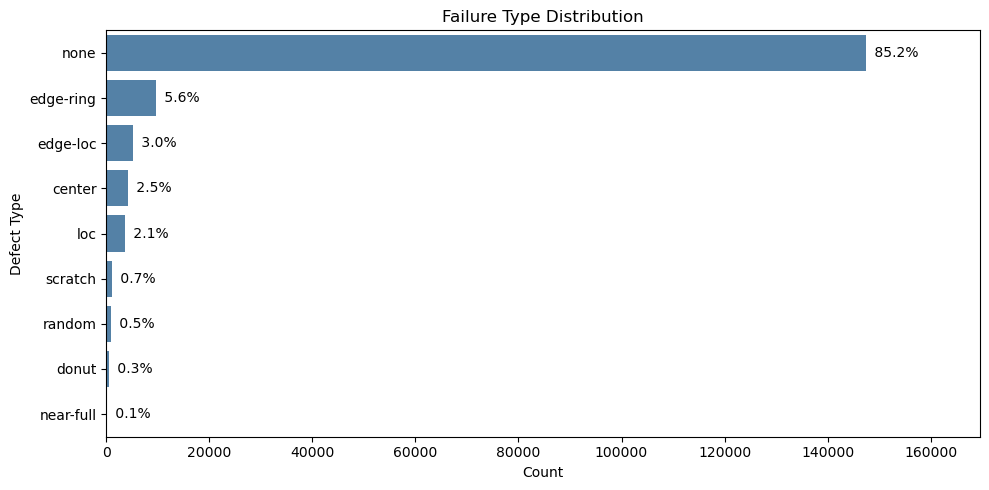

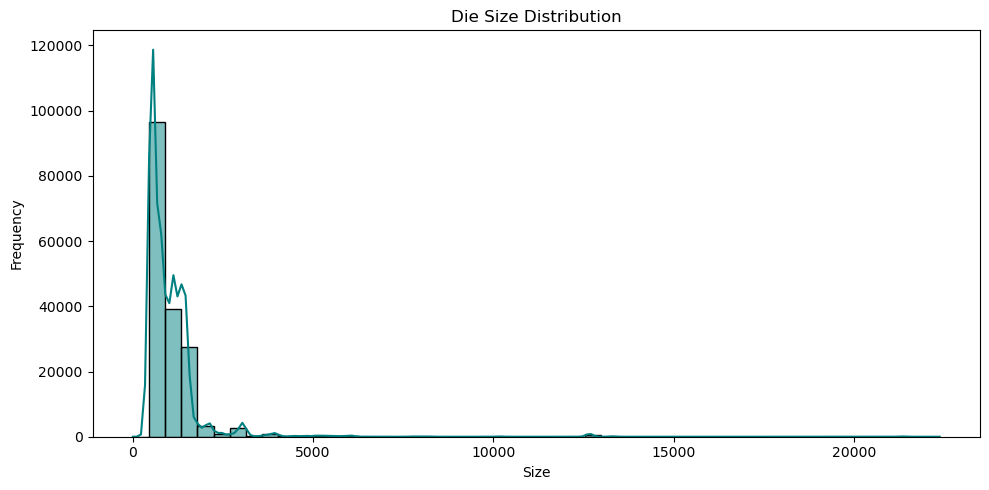

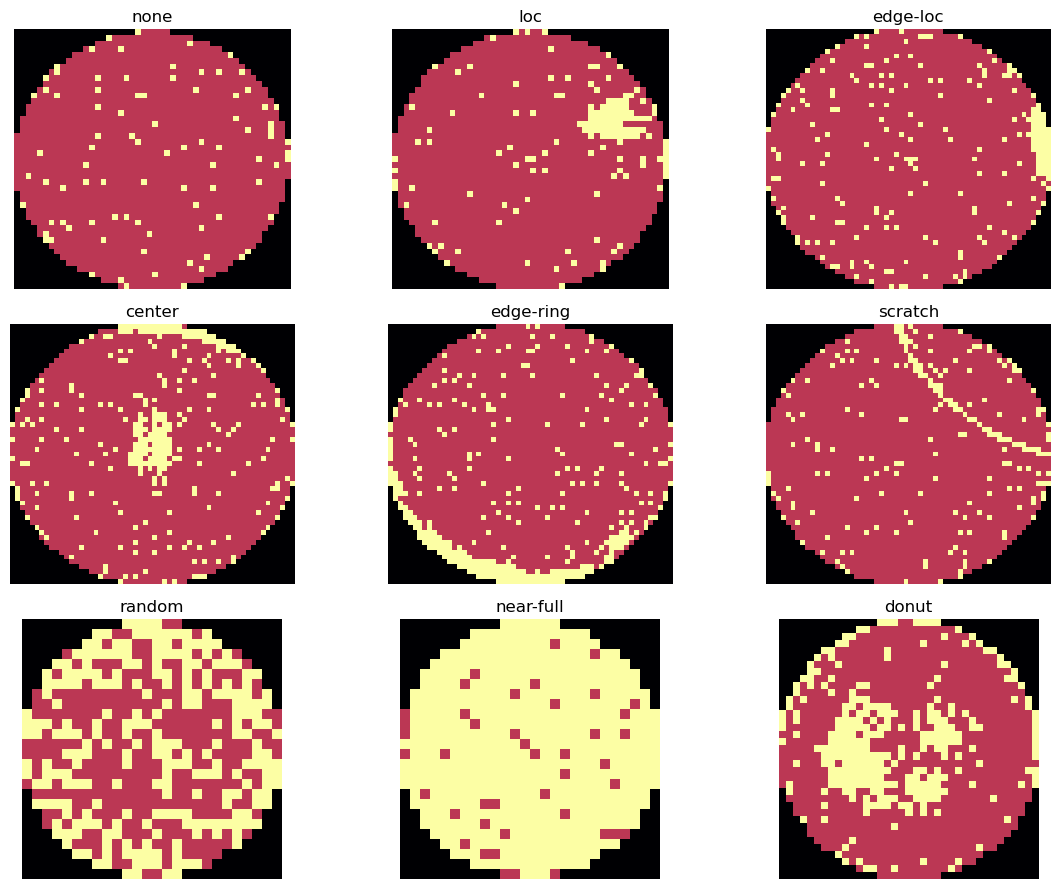

In [7]:
statistical_analysis(df)
visualize_wafer_samples(df)

### Tipi di Fallimento (Failure Types) nel Dataset WM-811K

* **none (147.431)**
Il wafer è considerato sano. Può contenere chip difettosi, ma sono isolati e non formano alcun pattern geometrico sistematico legato a malfunzionamenti dei macchinari.
* **edge-ring (9.680)**
I chip difettosi formano un anello continuo (o quasi continuo) lungo tutto il perimetro esterno del disco. È un difetto tipicamente legato a problemi fisici o chimici che colpiscono i bordi durante la lavorazione.
* **edge-loc (5.189)**
Un agglomerato (cluster) di difetti concentrato in una zona specifica e circoscritta del bordo esterno, ma che non è abbastanza esteso da formare un anello completo.
* **center (4.294)**
Un blocco compatto di chip difettosi situato esattamente nella zona centrale del wafer.
* **loc (3.593)**
*Localizzato*. Un grappolo denso e asimmetrico di difetti concentrato in un punto specifico della superficie, che non si trova né esattamente al centro né sul bordo.
* **scratch (1.193)**
*Graffio*. Una linea sottile o una striscia di difetti che attraversa il disco. È spesso il risultato di un danno meccanico o fisico, ad esempio causato dalla manipolazione del wafer da parte di un braccio robotico.
* **random (866)**
Difetti sparsi in modo casuale su tutta la mappa. A differenza di `none`, qui la quantità di difetti è rilevante, ma continuano a non formare alcuna forma geometrica o raggruppamento chiaro.
* **donut (555)**
*Ciambella*. I difetti formano un anello, ma a differenza dell'edge-ring, questo anello si trova a metà strada tra il centro e il bordo del wafer.
* **near-full (149)**
Un guasto critico e massivo. La quasi totalità dei microchip sul wafer risulta difettosa, indicando un grave problema durante l'intero processo per quel lotto.